# nnU-Net: Lung Nodule Segmentation on RexGrounding-CT

This notebook covers:
1. Environment setup and variable configuration
2. Dataset conversion from RexGrounding-CT lung-nodule manifest -> nnU-Net format
3. Dataset fingerprinting and preprocessing
4. Model training commands
5. Finding the best configuration
6. Inference, postprocessing, and evaluation

---
**Dataset specifics handled here:**
- Uses `lung_nodule_ct_scans.json`, currently category `2d` only
- Source `train` entries become nnU-Net training cases
- Existing local source `val` entries are mapped to the notebook test set
- Multi-finding masks (F x H x W x D) are collapsed by `nodule_channels`
- Instance-coded mask values -> binary semantic mask (0/1)
- HU-valued CT volumes


## 0. Install dependencies


Install dependencies in the terminal

```
uv venv --python 3.12.12
source .venv/bin/activate
uv add torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
uv add nnunetv2
```

Optional: network topology visualisation
pip install --upgrade git+https://github.com/FabianIsensee/hiddenlayer.git


In [1]:
# Install dependencies in the terminal

# uv venv --python 3.12.12
# source .venv/bin/activate
# uv add tqdm nibabel numpy matplotlib
# uv add torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu132
# uv add nnunetv2cleare

# Optional: network topology visualisation
# pip install --upgrade git+https://github.com/FabianIsensee/hiddenlayer.git


## 1. Configuration — edit these paths before running anything else


In [2]:
import os
import pathlib
import sys

# ------------------------------------------------------------------ #
#  Lung nodule dataset configuration
# ------------------------------------------------------------------ #

SPLIT_JSON = r"/home/chest_ct/code/data/rexgrounding-ct/lung_nodule_ct_scans_train120.json"

CT_ROOT  = r"/home/chest_ct/code/data/data_volumes/dataset/train_fixed"
SEG_ROOT = r"/home/chest_ct/code/data/segmentations/segmentations"

NNUNET_RAW          = r"/home/chest_ct/code/models/nnu-net/storage/nnUNet_raw"
NNUNET_PREPROCESSED = r"/home/chest_ct/code/models/nnu-net/storage/nnUNet_preprocessed"
NNUNET_RESULTS      = r"/home/chest_ct/code/models/nnu-net/storage/nnUNet_results"

# Smaller subset dataset.
DATASET_ID   = 103
DATASET_NAME = "LungNodules2DSubset120"
TRAIN_CASE_LIMIT = 120

# Train 2D only. Avoid 3d_fullres because it filled disk.
CONFIGURATION = "3d_fullres"
N_FOLDS       = 5
CUDA_DEVICE   = 0

# ------------------------------------------------------------------ #

DATASET_FULL_NAME = f"Dataset{DATASET_ID:03d}_{DATASET_NAME}"
DATASET_RAW_DIR   = os.path.join(NNUNET_RAW, DATASET_FULL_NAME)

for d in [NNUNET_RAW, NNUNET_PREPROCESSED, NNUNET_RESULTS]:
    os.makedirs(d, exist_ok=True)

os.environ["nnUNet_raw"]          = NNUNET_RAW
os.environ["nnUNet_preprocessed"] = NNUNET_PREPROCESSED
os.environ["nnUNet_results"]      = NNUNET_RESULTS

print("Dataset folder:", DATASET_RAW_DIR)
print("Manifest:", SPLIT_JSON)
print("Training cases limit:", TRAIN_CASE_LIMIT)
print("Configuration:", CONFIGURATION)
print("Environment variables set.")

Dataset folder: /home/chest_ct/code/models/nnu-net/storage/nnUNet_raw/Dataset103_LungNodules2DSubset120
Manifest: /home/chest_ct/code/data/rexgrounding-ct/lung_nodule_ct_scans_train120.json
Training cases limit: 120
Configuration: 3d_fullres
Environment variables set.


## 2. Convert RexGrounding-CT Lung Nodules -> nnU-Net format

### Key design decisions

| Question | Choice |
|---|---|
| Which mask channels to use? | `nodule_channels` from `lung_nodule_ct_scans.json` |
| Which category? | `2d` only: solitary pulmonary nodule or mass |
| Instance values -> semantic? | Any non-zero pixel in any nodule channel becomes label `1` |
| Multi-finding overlap? | Union — a voxel active in any selected channel is foreground |
| Modality string | `CT` (nnU-Net applies HU-aware normalisation automatically) |
| File suffix | `.nii.gz` |
| Case identifier | Stem of the volume filename, e.g. `train_13082_a_1` |


In [3]:
import json
import os
from pathlib import Path
import shutil

import nibabel as nib
import numpy as np
from tqdm.auto import tqdm


def extract_nodule_mask(seg_path: str, nodule_channels: list[int]) -> np.ndarray:
    """
    Load a multi-finding mask (F x H x W x D) and collapse the selected
    nodule channels into a binary semantic mask (H x W x D).

    Background = 0, lung_nodule foreground = 1.
    """
    img = nib.load(seg_path)
    data = img.dataobj

    if len(img.shape) == 3:
        if nodule_channels != [0]:
            raise ValueError(f"{seg_path} is 3D but requested channels {nodule_channels}")
        return (np.asanyarray(data) > 0).astype(np.uint8)

    if len(img.shape) != 4:
        raise ValueError(f"Expected 3D or 4D segmentation, got {img.shape}: {seg_path}")

    binary = np.zeros(img.shape[1:], dtype=bool)
    for ch in nodule_channels:
        if ch >= img.shape[0]:
            raise ValueError(f"Channel {ch} out of range for {seg_path} with shape {img.shape}")
        binary |= np.asanyarray(data[ch]) > 0

    return binary.astype(np.uint8)


def resolve_local_paths(entry: dict) -> tuple[Path, Path]:
    """Use manifest paths first; fall back to building paths from the filename."""
    if entry.get("ct_path") and entry.get("seg_path"):
        return Path(entry["ct_path"]), Path(entry["seg_path"])

    raw_name = entry["name"]
    case_id = raw_name.replace(".nii.gz", "")
    parts = case_id.split("_")
    train_dir = "_".join(parts[:2])
    series_dir = "_".join(parts[:-1])
    ct_path = Path(CT_ROOT) / train_dir / series_dir / raw_name
    seg_path = Path(SEG_ROOT) / raw_name
    return ct_path, seg_path


def link_or_copy_ct(ct_path: Path, ct_dest: Path, mode: str = "hardlink") -> None:
    """Hardlink CT files by default to avoid duplicating large volumes."""
    if ct_dest.exists():
        return
    ct_dest.parent.mkdir(parents=True, exist_ok=True)
    if mode == "hardlink":
        try:
            os.link(ct_path, ct_dest)
            return
        except OSError:
            pass
    shutil.copy2(ct_path, ct_dest)


def convert_split(
    entries: list[dict],
    images_out: Path,
    labels_out: Path | None,
    desc: str = "Converting",
    skip_missing: bool = True,
) -> list[str]:
    """Convert manifest entries into nnU-Net image/label files."""
    images_out.mkdir(parents=True, exist_ok=True)
    if labels_out is not None:
        labels_out.mkdir(parents=True, exist_ok=True)

    case_ids = []
    for entry in tqdm(entries, desc=desc):
        raw_name = entry["name"]
        case_id = entry.get("case_id", raw_name.replace(".nii.gz", ""))
        ct_path, seg_path = resolve_local_paths(entry)
        channels = entry["nodule_channels"]

        if not ct_path.is_file():
            if skip_missing:
                print(f"  [SKIP] CT not found: {ct_path}")
                continue
            raise FileNotFoundError(ct_path)

        ct_dest = images_out / f"{case_id}_0000.nii.gz"
        link_or_copy_ct(ct_path, ct_dest)

        if labels_out is not None:
            if not seg_path.is_file():
                if skip_missing:
                    print(f"  [SKIP] Seg not found: {seg_path}")
                    continue
                raise FileNotFoundError(seg_path)

            lbl_dest = labels_out / f"{case_id}.nii.gz"
            if not lbl_dest.exists():
                binary = extract_nodule_mask(str(seg_path), channels)
                ct_img = nib.load(str(ct_dest))
                if binary.shape != ct_img.shape:
                    raise ValueError(
                        f"Shape mismatch for {case_id}: CT {ct_img.shape}, label {binary.shape}"
                    )
                lbl_img = nib.Nifti1Image(binary, ct_img.affine, ct_img.header.copy())
                lbl_img.set_data_dtype(np.uint8)
                nib.save(lbl_img, str(lbl_dest))

        case_ids.append(case_id)

    return case_ids


# Load lung-nodule manifest.
with open(SPLIT_JSON) as f:
    manifest = json.load(f)

assert manifest.get("target_categories") == ["2d"], manifest.get("target_categories")
split_data = manifest["splits"]
train_entries = split_data.get("train", [])
val_entries = split_data.get("val", [])
test_entries = split_data.get("test", [])

print("Manifest split policy:", manifest.get("split_policy"))
print(f"Train : {len(train_entries)} cases")
print(f"Valid : {len(val_entries)} cases")
print(f"Test  : {len(test_entries)} cases")
print("All test CTs exist:", all(Path(e["ct_path"]).is_file() for e in test_entries))


Manifest split policy: source train -> train; source val -> test; source test ignored unless local
Train : 120 cases
Valid : 0 cases
Test  : 13 cases
All test CTs exist: True


In [4]:
# Convert train entries to imagesTr/labelsTr.
# Convert test entries to imagesTs/labelsTs so we can evaluate later.
# nnU-Net internally creates CV splits from imagesTr/labelsTr.

images_tr = Path(DATASET_RAW_DIR) / "imagesTr"
labels_tr = Path(DATASET_RAW_DIR) / "labelsTr"
images_ts = Path(DATASET_RAW_DIR) / "imagesTs"
labels_ts = Path(DATASET_RAW_DIR) / "labelsTs"

train_cases = convert_split(
    train_entries,
    images_tr,
    labels_tr,
    desc="Train",
)

test_cases = convert_split(
    test_entries,
    images_ts,
    labels_ts,
    desc="Test",
)

print()
print("Conversion complete.")
print(f"  Training cases : {len(train_cases)}")
print(f"  Test images    : {len(test_cases)}")


Train:   0%|          | 0/120 [00:00<?, ?it/s]

Test:   0%|          | 0/13 [00:00<?, ?it/s]


Conversion complete.
  Training cases : 120
  Test images    : 13


In [5]:
# Write dataset.json. nnU-Net v2 requires this file in the dataset root.

from nnunetv2.dataset_conversion.generate_dataset_json import generate_dataset_json

generate_dataset_json(
    output_folder=DATASET_RAW_DIR,
    channel_names={0: "CT"},
    labels={"background": 0, "lung_nodule": 1},
    num_training_cases=len(train_cases),
    file_ending=".nii.gz",
    dataset_name=DATASET_FULL_NAME,
    reference="RexGrounding-CT",
    description="Binary 2d lung nodule segmentation extracted from RexGrounding-CT masks",
)

print("dataset.json written to:", DATASET_RAW_DIR)


dataset.json written to: /home/chest_ct/code/models/nnu-net/storage/nnUNet_raw/Dataset103_LungNodules2DSubset120


In [6]:
# Sanity-check: inspect a single converted case.
import nibabel as nib
import numpy as np

assert train_cases, "No training cases were converted."
sample_case = train_cases[0]
ct_img = nib.load(str(images_tr / f"{sample_case}_0000.nii.gz"))
lbl_img = nib.load(str(labels_tr / f"{sample_case}.nii.gz"))

ct_arr = ct_img.get_fdata()
lbl_arr = np.asanyarray(lbl_img.dataobj)

print(f"Case : {sample_case}")
print(f"CT   shape : {ct_arr.shape}  | dtype: {ct_arr.dtype}")
print(f"Label shape: {lbl_arr.shape} | dtype: {lbl_arr.dtype}")
print(f"CT HU range: [{ct_arr.min():.0f}, {ct_arr.max():.0f}]")
print(f"Label unique values: {np.unique(lbl_arr)}")
print(f"Lung nodule voxel fraction : {(lbl_arr > 0).mean():.6%}")

assert ct_arr.shape == lbl_arr.shape, "Shape mismatch between CT and label!"
assert set(np.unique(lbl_arr)).issubset({0, 1}), "Labels must be binary 0/1."
print()
print("Shapes and labels look correct.")


Case : train_340_a_1
CT   shape : (768, 768, 215)  | dtype: float64
Label shape: (768, 768, 215) | dtype: uint8
CT HU range: [-1024, 3071]
Label unique values: [0 1]
Lung nodule voxel fraction : 0.805398%

Shapes and labels look correct.


## 3. Plan and preprocess

This extracts the dataset fingerprint, automatically selects patch sizes / batch sizes / normalisation, and writes preprocessed data to `nnUNet_preprocessed`.

> **Runtime:** expect 10–60 min depending on the number of cases and disk speed.


In [7]:
# Verify integrity and run plan+preprocess in one step.
# This cell reports preprocessing status. It does not auto-run preprocessing
# during "Run All" because preprocessing can take a long time.
import pathlib

AUTO_RUN_PREPROCESSING = False

plans_path = pathlib.Path(NNUNET_PREPROCESSED) / DATASET_FULL_NAME / "nnUNetPlans.json"
preproc_root = pathlib.Path(NNUNET_PREPROCESSED) / DATASET_FULL_NAME
fullres_dir = preproc_root / "nnUNetPlans_3d_fullres"
twod_dir = preproc_root / "nnUNetPlans_2d"

fullres_cases = len(list(fullres_dir.glob("*.b2nd"))) if fullres_dir.exists() else 0
twod_cases = len(list(twod_dir.glob("*.b2nd"))) if twod_dir.exists() else 0
expected_cases = len(train_cases) if "train_cases" in globals() else 0

print("Plans:", plans_path)
print("Plans exists:", plans_path.exists())
print("Expected training cases:", expected_cases)
print("3d_fullres data files:", fullres_cases)
print("2d data files:", twod_cases)

preprocess_cmd = (
    f"nnUNetv2_plan_and_preprocess -d {DATASET_ID} "
    f"--verify_dataset_integrity -c 3d_fullres 2d -np 2 2 --no_pbar"
)

if expected_cases and plans_path.exists() and fullres_cases >= expected_cases and twod_cases >= expected_cases:
    print("Preprocessing appears complete; skipping nnUNetv2_plan_and_preprocess.")
elif AUTO_RUN_PREPROCESSING:
    print("Preprocessing outputs are missing/incomplete; running:")
    print(preprocess_cmd)
    !nnUNetv2_plan_and_preprocess         -d {DATASET_ID}         --verify_dataset_integrity         -c 3d_fullres 2d         -np 2 2         --no_pbar
else:
    print("Preprocessing outputs are missing/incomplete, but AUTO_RUN_PREPROCESSING is False.")
    print("Run this manually if needed:")
    print(" ", preprocess_cmd)


Plans: /home/chest_ct/code/models/nnu-net/storage/nnUNet_preprocessed/Dataset103_LungNodules2DSubset120/nnUNetPlans.json
Plans exists: True
Expected training cases: 120
3d_fullres data files: 240
2d data files: 240
Preprocessing appears complete; skipping nnUNetv2_plan_and_preprocess.


In [8]:
# Inspect what was planned
import json
import pathlib

plans_path = pathlib.Path(NNUNET_PREPROCESSED) / DATASET_FULL_NAME / "nnUNetPlans.json"
with open(plans_path) as f:
    plans = json.load(f)

for cfg_name, cfg in plans["configurations"].items():
    print(f"\n── {cfg_name} ─────────────────────")
    print(f"  patch_size          : {cfg.get('patch_size')}")
    print(f"  batch_size          : {cfg.get('batch_size')}")
    print(f"  normalization       : {cfg.get('normalization_schemes')}")
    print(f"  spacing             : {cfg.get('spacing')}")



── 2d ─────────────────────
  patch_size          : [640, 640]
  batch_size          : 8
  normalization       : ['CTNormalization']
  spacing             : [0.68359375, 0.68359375]

── 3d_lowres ─────────────────────
  patch_size          : [128, 128, 128]
  batch_size          : 2
  normalization       : ['CTNormalization']
  spacing             : [1.8750602589940135, 1.7090392985622525, 1.7090392985622525]

── 3d_fullres ─────────────────────
  patch_size          : [128, 128, 128]
  batch_size          : 2
  normalization       : ['CTNormalization']
  spacing             : [0.75, 0.68359375, 0.68359375]

── 3d_cascade_fullres ─────────────────────
  patch_size          : None
  batch_size          : None
  normalization       : None
  spacing             : None


## 4. Train — 5-fold cross-validation

Each fold takes several hours on a modern GPU. Run folds in parallel across multiple GPUs by opening separate terminals (or Jupyter kernels) and setting `CUDA_VISIBLE_DEVICES` for each.

`--npz` saves validation softmax probabilities — **required** for `nnUNetv2_find_best_configuration`.


In [9]:
# ── Safe training launcher ─────────────────────────────────────────
# Full 5-fold training takes ~31 hours on this machine. This cell does NOT
# auto-start long training when "Run All" is used.
#
# To train a shorter first model manually, copy one of the printed commands
# into a terminal.

TRAIN_FOLDS = [0, 1, 2, 3, 4]
SHORT_TRAINER = "nnUNetTrainer_250epochs"  # alternatives: nnUNetTrainer_100epochs, nnUNetTrainer_500epochs
AUTO_RUN_TRAINING = True

for fold in TRAIN_FOLDS:
    short_cmd = (
        f"CUDA_VISIBLE_DEVICES={CUDA_DEVICE} "
        f"nnUNetv2_train {DATASET_ID} {CONFIGURATION} {fold} "
        f"-tr {SHORT_TRAINER} --npz"
    )
    full_cmd = (
        f"CUDA_VISIBLE_DEVICES={CUDA_DEVICE} "
        f"nnUNetv2_train {DATASET_ID} {CONFIGURATION} {fold} --npz"
    )
    print(f"Fold {fold} short command:")
    print(" ", short_cmd)
    print(f"Fold {fold} full 1000-epoch command:")
    print(" ", full_cmd)

if AUTO_RUN_TRAINING:
    for fold in TRAIN_FOLDS:
        !CUDA_VISIBLE_DEVICES={CUDA_DEVICE} nnUNetv2_train \
            {DATASET_ID} {CONFIGURATION} {fold} \
            -tr {SHORT_TRAINER} \
            --npz
else:
    print("\nAUTO_RUN_TRAINING is False, so no training was started from this notebook run.")


Fold 0 short command:
  CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 103 3d_fullres 0 -tr nnUNetTrainer_250epochs --npz
Fold 0 full 1000-epoch command:
  CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 103 3d_fullres 0 --npz
Fold 1 short command:
  CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 103 3d_fullres 1 -tr nnUNetTrainer_250epochs --npz
Fold 1 full 1000-epoch command:
  CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 103 3d_fullres 1 --npz
Fold 2 short command:
  CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 103 3d_fullres 2 -tr nnUNetTrainer_250epochs --npz
Fold 2 full 1000-epoch command:
  CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 103 3d_fullres 2 --npz
Fold 3 short command:
  CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 103 3d_fullres 3 -tr nnUNetTrainer_250epochs --npz
Fold 3 full 1000-epoch command:
  CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 103 3d_fullres 3 --npz
Fold 4 short command:
  CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 103 3d_fullres 4 -tr nnUNetTrainer_250epochs --npz
Fold 4 full 1000-epoch command:
  CUDA_VISIBLE_DEVICES=

In [10]:
# ── Commands for manual fold training ──────────────────────────────
print("Short 250-epoch commands:")
for fold in range(N_FOLDS):
    print(
        f"CUDA_VISIBLE_DEVICES={CUDA_DEVICE} "
        f"nnUNetv2_train {DATASET_ID} {CONFIGURATION} {fold} "
        f"-tr nnUNetTrainer_250epochs --npz"
    )

print("\nFull 1000-epoch commands:")
for fold in range(N_FOLDS):
    print(
        f"CUDA_VISIBLE_DEVICES={CUDA_DEVICE} "
        f"nnUNetv2_train {DATASET_ID} {CONFIGURATION} {fold} --npz"
    )


Short 250-epoch commands:
CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 103 3d_fullres 0 -tr nnUNetTrainer_250epochs --npz
CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 103 3d_fullres 1 -tr nnUNetTrainer_250epochs --npz
CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 103 3d_fullres 2 -tr nnUNetTrainer_250epochs --npz
CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 103 3d_fullres 3 -tr nnUNetTrainer_250epochs --npz
CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 103 3d_fullres 4 -tr nnUNetTrainer_250epochs --npz

Full 1000-epoch commands:
CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 103 3d_fullres 0 --npz
CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 103 3d_fullres 1 --npz
CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 103 3d_fullres 2 --npz
CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 103 3d_fullres 3 --npz
CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 103 3d_fullres 4 --npz


In [22]:
# ── Monitor training progress ──────────────────────────────────────
import json
import pathlib

results_root = pathlib.Path(NNUNET_RESULTS)

for fold in range(N_FOLDS):
    fold_dir = (
        results_root
        / DATASET_FULL_NAME
        / f"nnUNetTrainer__nnUNetPlans__{CONFIGURATION}"
        / f"fold_{fold}"
    )
    summary_path = fold_dir / "validation" / "summary.json"
    logs = sorted(fold_dir.glob("training_log_*.txt"))
    ckpt_best = fold_dir / "checkpoint_best.pth"
    ckpt_final = fold_dir / "checkpoint_final.pth"

    print(f"\nFold {fold}")
    print("  folder:", fold_dir)
    print("  checkpoint_best:", ckpt_best.exists())
    print("  checkpoint_final:", ckpt_final.exists())

    if summary_path.exists():
        with open(summary_path) as f:
            s = json.load(f)
        fg = s.get("foreground_mean", {})
        dice = fg.get("Dice", fg.get("dice", "N/A"))
        print(f"  Validation Dice (foreground mean): {dice}")
    elif logs:
        print("  summary.json not found; training is not complete.")
        print("  latest log:", logs[-1])
        tail_lines = logs[-1].read_text().splitlines()[-8:]
        for line in tail_lines:
            print("   ", line)
    else:
        print("  No training log found.")



Fold 0
  folder: /home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset103_LungNodules2DSubset120/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0
  checkpoint_best: False
  checkpoint_final: False
  No training log found.

Fold 1
  folder: /home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset103_LungNodules2DSubset120/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_1
  checkpoint_best: False
  checkpoint_final: False
  No training log found.

Fold 2
  folder: /home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset103_LungNodules2DSubset120/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_2
  checkpoint_best: False
  checkpoint_final: False
  No training log found.

Fold 3
  folder: /home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset103_LungNodules2DSubset120/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_3
  checkpoint_best: False
  checkpoint_final: False
  No training log found.

Fold 4
  folder: /home/chest_ct/code/models/nnu-net/storage/nnUNet_resu

## 5. Find the best configuration (optional but recommended)


In [24]:
# This compares completed trained configurations and writes inference_instructions.txt.
# It is skipped until at least one validation summary exists.
trainer_root = pathlib.Path(NNUNET_RESULTS) / DATASET_FULL_NAME
summaries = list(trainer_root.glob("**/validation/summary.json"))

if summaries:
    print(summaries)
    !nnUNetv2_find_best_configuration 103 \
    -c 3d_fullres \
    -tr nnUNetTrainer_250epochs \
    --disable_ensembling
else:
    print("No completed validation summaries found; skipping find_best_configuration.")


[PosixPath('/home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset103_LungNodules2DSubset120/nnUNetTrainer_250epochs__nnUNetPlans__3d_fullres/fold_2/validation/summary.json'), PosixPath('/home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset103_LungNodules2DSubset120/nnUNetTrainer_250epochs__nnUNetPlans__3d_fullres/fold_0/validation/summary.json'), PosixPath('/home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset103_LungNodules2DSubset120/nnUNetTrainer_250epochs__nnUNetPlans__3d_fullres/fold_3/validation/summary.json'), PosixPath('/home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset103_LungNodules2DSubset120/nnUNetTrainer_250epochs__nnUNetPlans__3d_fullres/fold_4/validation/summary.json'), PosixPath('/home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset103_LungNodules2DSubset120/nnUNetTrainer_250epochs__nnUNetPlans__3d_fullres/fold_1/validation/summary.json')]

***All results:***
nnUNetTrainer_250epochs__nnUNetPlans__3d_fullres:

In [13]:
# Read the recommended inference command
instructions_path = pathlib.Path(NNUNET_RESULTS) / DATASET_FULL_NAME / "inference_instructions.txt"
if instructions_path.exists():
    print(instructions_path.read_text())
else:
    print("inference_instructions.txt not found — did find_best_configuration complete?")


inference_instructions.txt not found — did find_best_configuration complete?


## 6. Inference

Input images must follow the same naming convention used during training:
`<case_id>_0000.nii.gz`


In [14]:
# ── Define inference I/O ───────────────────────────────────────────
INFER_INPUT_FOLDER  = str(images_ts)   # imagesTs prepared during conversion
INFER_OUTPUT_FOLDER = os.path.join(NNUNET_RESULTS, DATASET_FULL_NAME, "predictions")

os.makedirs(INFER_OUTPUT_FOLDER, exist_ok=True)
print("Input :", INFER_INPUT_FOLDER)
print("Output:", INFER_OUTPUT_FOLDER)


Input : /home/chest_ct/code/models/nnu-net/storage/nnUNet_raw/Dataset103_LungNodules2DSubset120/imagesTs
Output: /home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset103_LungNodules2DSubset120/predictions


In [25]:
# Run inference. This is skipped until a completed checkpoint exists.
trainer_root = pathlib.Path(NNUNET_RESULTS) / DATASET_FULL_NAME
completed = sorted(
    trainer_root.glob(
        f"{SHORT_TRAINER}__nnUNetPlans__{CONFIGURATION}/fold_*/checkpoint_final.pth"
    )
)

completed_folds = sorted({p.parent.name.removeprefix("fold_") for p in completed})

if completed_folds:
    folds_arg = " ".join(completed_folds)
    print("Using folds:", folds_arg)

    !nnUNetv2_predict \
        -d {DATASET_ID} \
        -i "{INFER_INPUT_FOLDER}" \
        -o "{INFER_OUTPUT_FOLDER}" \
        -f {folds_arg} \
        -tr {SHORT_TRAINER} \
        -c {CONFIGURATION} \
        -p nnUNetPlans
else:
    print("No checkpoint_final.pth found; skipping inference.")
    print("Finish training first, then run this cell.")

Using folds: 0 1 2 3 4

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 13 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 13 cases that I would like to predict

Predicting train_12994_a_1:
perform_everything_on_device: True
100%|█████████████████████████████████████████| 567/567 [01:12<00:00,  7.86it/s]
sending off prediction to background worker for resampling and export
done with train_12994_a_1

Predicting train_13013_a_1:
perform_everything_on_device: True
100%|█████████████████████████████████████████| 486/486 [01:01<00:00,  7.87it/s]
sending off prediction t

In [26]:
# Apply postprocessing if find_best_configuration was run.
trainer_folder = (
    pathlib.Path(NNUNET_RESULTS)
    / DATASET_FULL_NAME
    / f"nnUNetTrainer__nnUNetPlans__{CONFIGURATION}"
)

pp_pkl = list(trainer_folder.glob("**/postprocessing.pkl"))
if pp_pkl:
    pp_pkl = pp_pkl[0]
    plans_json = trainer_folder / "plans.json"
    dataset_json = pathlib.Path(DATASET_RAW_DIR) / "dataset.json"

    INFER_PP_OUTPUT = INFER_OUTPUT_FOLDER + "_pp"
    os.makedirs(INFER_PP_OUTPUT, exist_ok=True)

    !nnUNetv2_apply_postprocessing         -i  "{INFER_OUTPUT_FOLDER}"         -o  "{INFER_PP_OUTPUT}"         -pp_pkl_file "{pp_pkl}"         -plans_json "{plans_json}"         -dataset_json "{dataset_json}"
else:
    print("No postprocessing.pkl found; skipping. Run find_best_configuration first.")


No postprocessing.pkl found; skipping. Run find_best_configuration first.


## 7. Evaluate predictions (using ground-truth labels for test set)


In [27]:
# Test labels were already written to labelsTs during conversion.
TEST_LABELS_DIR = pathlib.Path(DATASET_RAW_DIR) / "labelsTs"
print("Test labels dir:", TEST_LABELS_DIR)
print("Test labels:", len(list(TEST_LABELS_DIR.glob("*.nii.gz"))) if TEST_LABELS_DIR.exists() else 0)


Test labels dir: /home/chest_ct/code/models/nnu-net/storage/nnUNet_raw/Dataset103_LungNodules2DSubset120/labelsTs
Test labels: 13


In [28]:
from pathlib import Path
import os

import nibabel as nib
import numpy as np
import pandas as pd

INFER_OUTPUT_FOLDER = os.path.join(NNUNET_RESULTS, DATASET_FULL_NAME, "predictions")

def compute_binary_metrics(pred, gt):
    pred = pred > 0
    gt = gt > 0

    tp = int(np.logical_and(pred, gt).sum())
    fp = int(np.logical_and(pred, ~gt).sum())
    fn = int(np.logical_and(~pred, gt).sum())
    tn = int(np.logical_and(~pred, ~gt).sum())

    pred_voxels = int(pred.sum())
    gt_voxels = int(gt.sum())

    dice_denom = 2 * tp + fp + fn
    iou_denom = tp + fp + fn

    dice = (
        2 * tp / dice_denom
        if dice_denom > 0
        else np.nan
    )

    iou = (
        tp / iou_denom
        if iou_denom > 0
        else np.nan
    )

    precision = (
        tp / (tp + fp)
        if tp + fp > 0
        else 0.0
    )

    recall = (
        tp / (tp + fn)
        if tp + fn > 0
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if tn + fp > 0
        else np.nan
    )

    return {
        "pred_voxels": pred_voxels,
        "gt_voxels": gt_voxels,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "dice": dice,
        "iou": iou,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "prediction_empty": pred_voxels == 0,
        "gt_empty": gt_voxels == 0,
    }


pred_dir = Path(
    INFER_PP_OUTPUT
    if "INFER_PP_OUTPUT" in globals() and pp_pkl
    else INFER_OUTPUT_FOLDER
)

label_dir = Path(TEST_LABELS_DIR)

rows = []
missing = []

for gt_path in sorted(label_dir.glob("*.nii.gz")):
    case_id = gt_path.name.removesuffix(".nii.gz")
    pred_path = pred_dir / gt_path.name

    if not pred_path.exists():
        missing.append(case_id)
        continue

    gt = nib.load(str(gt_path)).get_fdata()
    pred = nib.load(str(pred_path)).get_fdata()

    if pred.shape != gt.shape:
        print(
            f"Skipping {case_id}: "
            f"prediction shape {pred.shape} != GT shape {gt.shape}"
        )
        continue

    metrics = compute_binary_metrics(pred, gt)

    rows.append({
        "case_id": case_id,
        **metrics,
    })


results_df = pd.DataFrame(rows)

print("Evaluated cases:", len(results_df))
print("Missing predictions:", len(missing))

if missing:
    print("Missing case IDs:", missing)


if not results_df.empty:
    print("\nPrediction status")
    print("=" * 70)

    print(
        "Empty predictions:",
        int(results_df["prediction_empty"].sum()),
        "/",
        len(results_df),
    )

    print(
        "Empty ground truths:",
        int(results_df["gt_empty"].sum()),
        "/",
        len(results_df),
    )

    print(
        "GT positive but prediction empty:",
        int(
            (
                ~results_df["gt_empty"]
                & results_df["prediction_empty"]
            ).sum()
        ),
        "/",
        len(results_df),
    )

    print("\nVoxel-level metrics")
    print("=" * 70)

    for metric in [
        "dice",
        "iou",
        "precision",
        "recall",
        "specificity",
    ]:
        values = results_df[metric].dropna()

        print(
            f"{metric.capitalize():12s} "
            f"mean={values.mean():.4f}  "
            f"std={values.std(ddof=0):.4f}  "
            f"median={values.median():.4f}  "
            f"min={values.min():.4f}  "
            f"max={values.max():.4f}"
        )

    print("\nPrediction and GT volume statistics")
    print("=" * 70)

    print(
        "Median predicted voxels:",
        int(results_df["pred_voxels"].median()),
    )

    print(
        "Median GT voxels:",
        int(results_df["gt_voxels"].median()),
    )

    print("\nWorst cases")
    display(
        results_df
        .sort_values("dice", ascending=True)
        .head(10)
    )

    print("\nBest cases")
    display(
        results_df
        .sort_values("dice", ascending=False)
        .head(10)
    )


Evaluated cases: 13
Missing predictions: 0

Prediction status
Empty predictions: 0 / 13
Empty ground truths: 0 / 13
GT positive but prediction empty: 0 / 13

Voxel-level metrics
Dice         mean=0.0401  std=0.1194  median=0.0000  min=0.0000  max=0.4525
Iou          mean=0.0252  std=0.0773  median=0.0000  min=0.0000  max=0.2924
Precision    mean=0.0266  std=0.0819  median=0.0000  min=0.0000  max=0.3098
Recall       mean=0.2311  std=0.3891  median=0.0000  min=0.0000  max=1.0000
Specificity  mean=0.9998  std=0.0002  median=0.9999  min=0.9993  max=1.0000

Prediction and GT volume statistics
Median predicted voxels: 10068
Median GT voxels: 222

Worst cases


,case_id,pred_voxels,gt_voxels,tp,fp,fn,tn,dice,iou,precision,recall,specificity,prediction_empty,gt_empty
0,train_12994_a_1,5635,639,0,5635,639,140961662,0.000000,0.000000,0.000000,0.000000,0.999960,False,False
3,train_13082_a_1,4792,55,0,4792,55,53734673,0.000000,0.000000,0.000000,0.000000,0.999911,False,False
6,train_13119_c_1,63631,1040,0,63631,1040,85394273,0.000000,0.000000,0.000000,0.000000,0.999255,False,False
5,train_13113_a_1,8145,222,0,8145,222,87547729,0.000000,0.000000,0.000000,0.000000,0.999907,False,False
7,train_13155_a_2,6794,140,0,6794,140,58451178,0.000000,0.000000,0.000000,0.000000,0.999884,False,False
11,train_13492_b_2,34240,280,0,34240,280,121338152,0.000000,0.000000,0.000000,0.000000,0.999718,False,False
12,train_13624_a_2,4452,80,0,4452,80,122941004,0.000000,0.000000,0.000000,0.000000,0.999964,False,False
2,train_13035_a_1,11435,33,2,11433,31,56087350,0.000349,0.000174,0.000175,0.060606,0.999796,False,False
8,train_13252_b_2,10068,2023,16,10052,2007,62640341,0.002647,0.001325,0.001589,0.007909,0.999840,False,False
1,train_13013_a_1,29002,163,158,28844,5,67866289,0.010835,0.005447,0.005448,0.969325,0.999575,False,False



Best cases


,case_id,pred_voxels,gt_voxels,tp,fp,fn,tn,dice,iou,precision,recall,specificity,prediction_empty,gt_empty
9,train_13316_a_2,12539,4634,3885,8654,749,58182680,0.452454,0.292369,0.309833,0.838369,0.999851,False,False
4,train_13092_a_2,8998,127,127,8871,0,53992666,0.027836,0.014114,0.014114,1.000000,0.999836,False,False
10,train_13398_a_1,12644,1505,193,12451,1312,85707132,0.027281,0.013829,0.015264,0.128239,0.999855,False,False
1,train_13013_a_1,29002,163,158,28844,5,67866289,0.010835,0.005447,0.005448,0.969325,0.999575,False,False
8,train_13252_b_2,10068,2023,16,10052,2007,62640341,0.002647,0.001325,0.001589,0.007909,0.999840,False,False
2,train_13035_a_1,11435,33,2,11433,31,56087350,0.000349,0.000174,0.000175,0.060606,0.999796,False,False
0,train_12994_a_1,5635,639,0,5635,639,140961662,0.000000,0.000000,0.000000,0.000000,0.999960,False,False
3,train_13082_a_1,4792,55,0,4792,55,53734673,0.000000,0.000000,0.000000,0.000000,0.999911,False,False
5,train_13113_a_1,8145,222,0,8145,222,87547729,0.000000,0.000000,0.000000,0.000000,0.999907,False,False
7,train_13155_a_2,6794,140,0,6794,140,58451178,0.000000,0.000000,0.000000,0.000000,0.999884,False,False


## 8. Visualise a prediction


In [ ]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
from ipywidgets import interact, IntSlider
  

# ============================================================
# 1. Find available prediction cases
# ============================================================
pred_dir = Path(INFER_PP_OUTPUT if pp_pkl else INFER_OUTPUT_FOLDER)
pred_files = sorted(pred_dir.glob("*.nii.gz"))

print("Prediction folder:", pred_dir)
print("Number of prediction files:", len(pred_files))

if len(pred_files) == 0:
    raise FileNotFoundError(f"No prediction files found in: {pred_dir}")

print("\nFirst 10 available prediction cases:")
for f in pred_files[:10]:
    print(" ", f.name.replace(".nii.gz", ""))


# ============================================================
# 2. Select one case
# ============================================================
case_id = pred_files[0].name.replace(".nii.gz", "")

# You can manually change this after checking printed names:
# case_id = "YOUR_CASE_ID"

ct_file = images_ts / f"{case_id}_0000.nii.gz"
pred_file = pred_dir / f"{case_id}.nii.gz"
gt_file = TEST_LABELS_DIR / f"{case_id}.nii.gz"

print("\nSelected case:", case_id)
print("CT  :", ct_file, "| exists:", ct_file.exists())
print("Pred:", pred_file, "| exists:", pred_file.exists())
print("GT  :", gt_file, "| exists:", gt_file.exists())

if not ct_file.exists():
    raise FileNotFoundError(f"CT file not found: {ct_file}")

if not pred_file.exists():
    raise FileNotFoundError(f"Prediction file not found: {pred_file}")

if not gt_file.exists():
    raise FileNotFoundError(f"GT file not found: {gt_file}")


# ============================================================
# 3. Load CT, prediction, and GT
# ============================================================
ct = nib.load(str(ct_file)).get_fdata()
pred = nib.load(str(pred_file)).get_fdata()
gt = nib.load(str(gt_file)).get_fdata()

print("\nOriginal CT shape  :", ct.shape)
print("Original Pred shape:", pred.shape)
print("Original GT shape  :", gt.shape)


# Prediction from nnU-Net is usually label mask
pred = pred > 0


# ============================================================
# 4. Handle 4D GT
# ============================================================
if gt.ndim == 4:
    print("GT is 4D. Combining all GT channels into one 3D mask.")
    gt = np.any(gt > 0, axis=0)
else:
    gt = gt > 0

print("\nFinal CT shape  :", ct.shape)
print("Final Pred shape:", pred.shape)
print("Final GT shape  :", gt.shape)

print("Total prediction voxels:", int(pred.sum()))
print("Total GT voxels        :", int(gt.sum()))


# ============================================================
# 5. Shape check
# ============================================================
if ct.shape != pred.shape:
    raise ValueError(f"Shape mismatch: CT {ct.shape}, Pred {pred.shape}")

if ct.shape != gt.shape:
    raise ValueError(f"Shape mismatch: CT {ct.shape}, GT {gt.shape}")


# ============================================================
# 6. Interactive CT + GT + Prediction viewer
# ============================================================
def show_ct_gt_pred_slice(z):
    hu_min, hu_max = -1000, 400

    ct_slice = np.clip(ct[:, :, z], hu_min, hu_max)
    ct_norm = (ct_slice - hu_min) / (hu_max - hu_min)
    ct_norm = np.clip(ct_norm, 0, 1)

    pred_slice = pred[:, :, z]
    gt_slice = gt[:, :, z]

    pred_only = pred_slice & ~gt_slice
    gt_only = gt_slice & ~pred_slice
    overlap = pred_slice & gt_slice

    intersection = int(overlap.sum())
    denom = int(pred_slice.sum() + gt_slice.sum())
    dice = (2 * intersection / denom) if denom > 0 else 1.0

    # Convert CT grayscale to RGB
    rgb = np.stack([ct_norm, ct_norm, ct_norm], axis=-1)

    # Red = prediction only
    alpha_pred = 0.60
    rgb[pred_only] = (
        (1 - alpha_pred) * rgb[pred_only]
        + alpha_pred * np.array([1, 0, 0])
    )

    # Yellow = overlap
    alpha_overlap = 0.85
    rgb[overlap] = (
        (1 - alpha_overlap) * rgb[overlap]
        + alpha_overlap * np.array([1, 1, 0])
    )

    plt.figure(figsize=(8, 8))

    plt.imshow(
        rgb.transpose(1, 0, 2),
        origin="lower"
    )

    # Green outline = GT
    if gt_slice.sum() > 0:
        plt.contour(
            gt_slice.T.astype(float),
            levels=[0.5],
            colors="lime",
            linewidths=2.5,
            origin="lower"
        )

    plt.title(
        f"{case_id}\n"
        f"Slice z={z}/{ct.shape[2]-1} | "
        f"Pred={int(pred_slice.sum())} | "
        f"GT={int(gt_slice.sum())} | "
        f"Overlap={intersection} | "
        f"Dice={dice:.3f}"
    )

    plt.axis("off")
    plt.show()


interact(
    show_ct_gt_pred_slice,
    z=IntSlider(
        min=0,
        max=ct.shape[2] - 1,
        step=1,
        value=ct.shape[2] // 2,
        description="Slice z",
        continuous_update=False
    )
)

Prediction folder: /home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset103_LungNodules2DSubset120/predictions
Number of prediction files: 13

First 10 available prediction cases:
  train_12994_a_1
  train_13013_a_1
  train_13035_a_1
  train_13082_a_1
  train_13092_a_2
  train_13113_a_1
  train_13119_c_1
  train_13155_a_2
  train_13252_b_2
  train_13316_a_2

Selected case: train_12994_a_1
CT  : /home/chest_ct/code/models/nnu-net/storage/nnUNet_raw/Dataset103_LungNodules2DSubset120/imagesTs/train_12994_a_1_0000.nii.gz | exists: True
Pred: /home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset103_LungNodules2DSubset120/predictions/train_12994_a_1.nii.gz | exists: True
GT  : /home/chest_ct/code/models/nnu-net/storage/nnUNet_raw/Dataset103_LungNodules2DSubset120/labelsTs/train_12994_a_1.nii.gz | exists: True

Original CT shape  : (768, 768, 239)
Original Pred shape: (768, 768, 239)
Original GT shape  : (768, 768, 239)

Final CT shape  : (768, 768, 239)
Final Pred sha

interactive(children=(IntSlider(value=119, continuous_update=False, description='Slice z', max=238), Output())…

<function __main__.show_ct_gt_pred_slice(z)>

CT folder: /home/chest_ct/code/models/nnu-net/storage/nnUNet_raw/Dataset103_LungNodules2DSubset120/imagesTs
GT folder: /home/chest_ct/code/models/nnu-net/storage/nnUNet_raw/Dataset103_LungNodules2DSubset120/labelsTs
Prediction folder: /home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset103_LungNodules2DSubset120/predictions
Prediction files found: 13
Added train_12994_a_1 | CT shape: (768, 768, 239) | GT voxels: 639 | Pred voxels: 5635
Added train_13013_a_1 | CT shape: (512, 512, 259) | GT voxels: 163 | Pred voxels: 29002
Added train_13035_a_1 | CT shape: (512, 512, 214) | GT voxels: 33 | Pred voxels: 11435
Added train_13082_a_1 | CT shape: (512, 512, 205) | GT voxels: 55 | Pred voxels: 4792
Added train_13092_a_2 | CT shape: (512, 512, 206) | GT voxels: 127 | Pred voxels: 8998
Added train_13113_a_1 | CT shape: (512, 512, 334) | GT voxels: 222 | Pred voxels: 8145


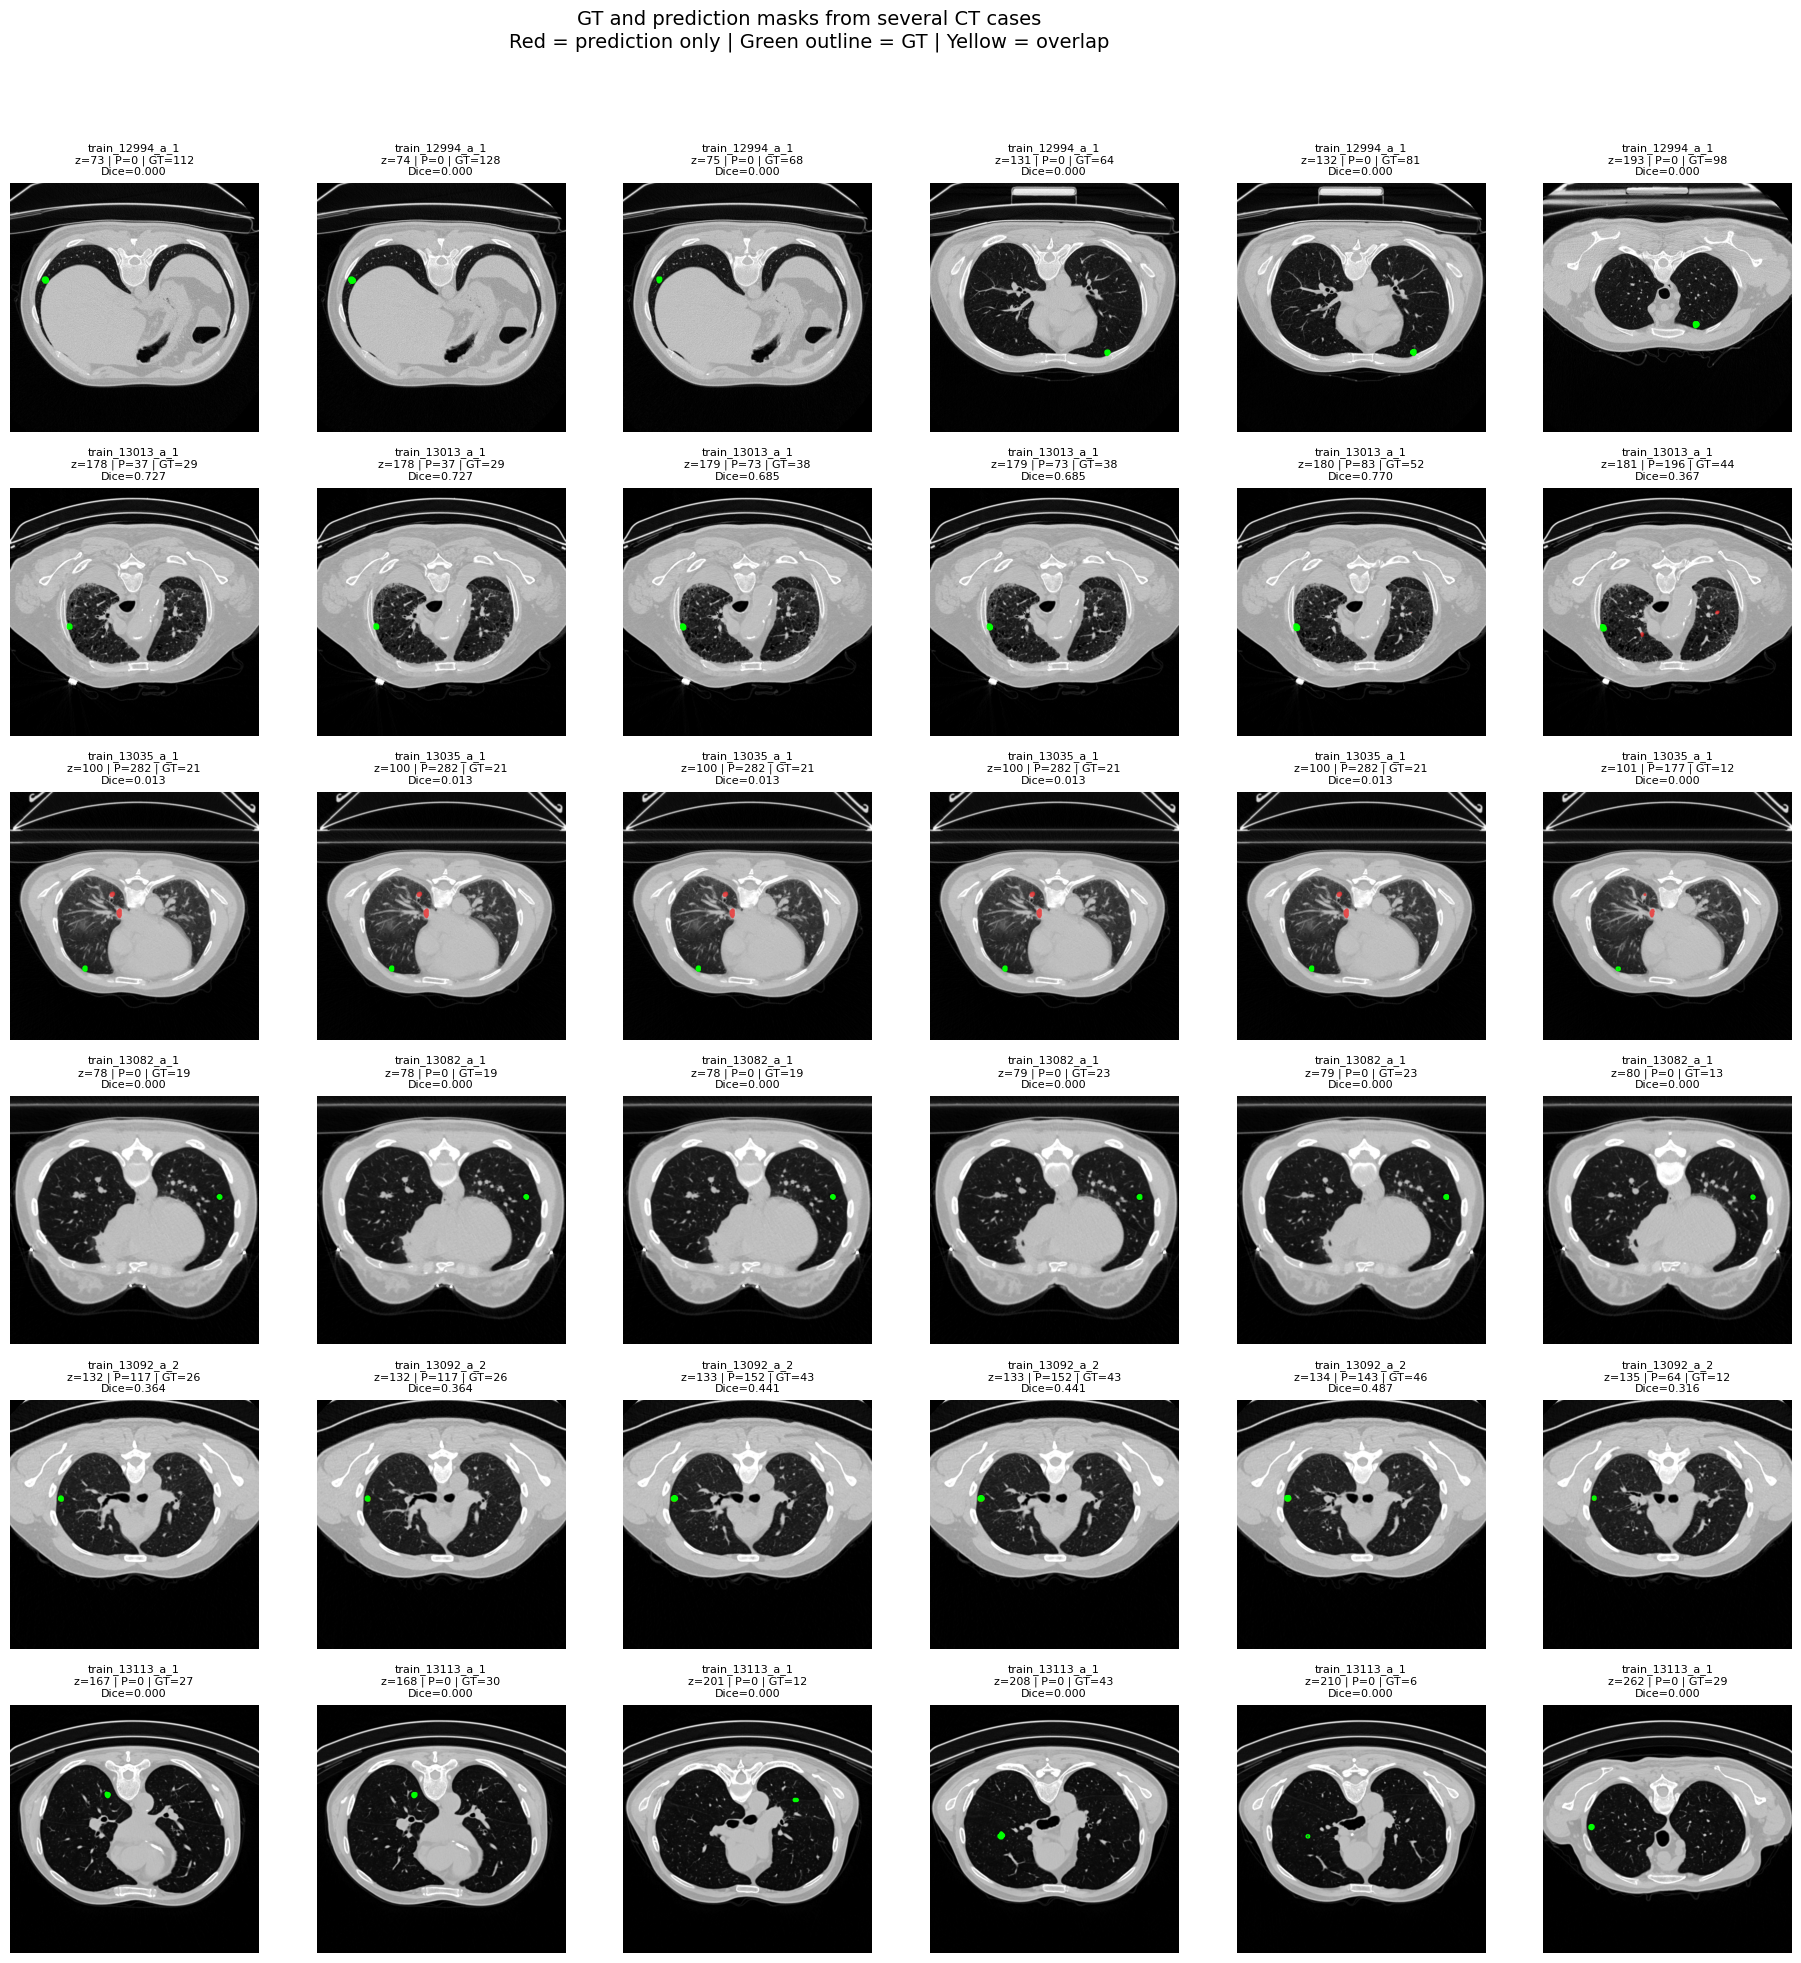

In [41]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# Full cell: Visualize GT + prediction masks from several cases
# ============================================================

def load_gt_3d(gt_path, mode="combine", channel=0):
    """
    Load GT mask and convert it to 3D.

    Supports:
        3D GT: (H, W, D)
        4D GT: (C, H, W, D)

    mode:
        "combine" -> combine all GT channels into one mask
        "channel" -> use one selected GT channel
    """

    gt = nib.load(str(gt_path)).get_fdata()

    if gt.ndim == 4:
        print(f"{gt_path.name} is 4D: {gt.shape}")

        if mode == "combine":
            gt = np.any(gt > 0, axis=0)
            print("  Using combined GT channels.")
        elif mode == "channel":
            gt = gt[channel] > 0
            print(f"  Using GT channel {channel}.")
        else:
            raise ValueError("mode must be 'combine' or 'channel'")
    else:
        gt = gt > 0

    return gt


def visualize_several_gt_pred_cases(
    images_ts,
    TEST_LABELS_DIR,
    pred_dir,
    num_cases=6,
    n_slices=6,
    hu_window=(-1000, 400),
    gt_mode="combine",
    gt_channel=0,
    select_slices_by="gt",
):
    """
    Visualize GT and prediction masks from several CT cases.

    One row = one case
    Columns = selected slices

    Green outline = GT
    Red fill      = prediction only
    Yellow fill   = overlap

    select_slices_by:
        "gt"      -> choose slices where GT exists
        "pred"    -> choose slices where prediction exists
        "both"    -> choose slices where GT or prediction exists
    """

    images_ts = Path(images_ts)
    TEST_LABELS_DIR = Path(TEST_LABELS_DIR)
    pred_dir = Path(pred_dir)

    pred_files = sorted(pred_dir.glob("*.nii.gz"))

    print("CT folder:", images_ts)
    print("GT folder:", TEST_LABELS_DIR)
    print("Prediction folder:", pred_dir)
    print("Prediction files found:", len(pred_files))

    if len(pred_files) == 0:
        raise FileNotFoundError(f"No prediction files found in {pred_dir}")

    cases = []

    for pred_file in pred_files:
        case_id = pred_file.name.replace(".nii.gz", "")

        ct_file = images_ts / f"{case_id}_0000.nii.gz"
        gt_file = TEST_LABELS_DIR / f"{case_id}.nii.gz"

        if not ct_file.exists():
            print(f"Skipping {case_id}: CT file not found")
            continue

        if not gt_file.exists():
            print(f"Skipping {case_id}: GT file not found")
            continue

        try:
            ct = nib.load(str(ct_file)).get_fdata()

            # Prediction from nnU-Net is usually label mask
            pred = nib.load(str(pred_file)).get_fdata()
            pred = pred > 0

            gt = load_gt_3d(
                gt_file,
                mode=gt_mode,
                channel=gt_channel,
            )

            if ct.shape != gt.shape:
                print(
                    f"Skipping {case_id}: CT/GT shape mismatch | "
                    f"CT {ct.shape}, GT {gt.shape}"
                )
                continue

            if ct.shape != pred.shape:
                print(
                    f"Skipping {case_id}: CT/Pred shape mismatch | "
                    f"CT {ct.shape}, Pred {pred.shape}"
                )
                continue

            gt_voxels = int(gt.sum())
            pred_voxels = int(pred.sum())

            if gt_voxels == 0 and pred_voxels == 0:
                print(f"Skipping {case_id}: both GT and prediction are empty")
                continue

            cases.append({
                "case_id": case_id,
                "ct": ct,
                "gt": gt,
                "pred": pred,
                "gt_voxels": gt_voxels,
                "pred_voxels": pred_voxels,
            })

            print(
                f"Added {case_id} | "
                f"CT shape: {ct.shape} | "
                f"GT voxels: {gt_voxels} | "
                f"Pred voxels: {pred_voxels}"
            )

            if len(cases) >= num_cases:
                break

        except Exception as e:
            print(f"Skipping {case_id} due to error: {e}")

    if len(cases) == 0:
        print("No valid cases found.")
        return

    nrows = len(cases)
    ncols = n_slices

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(ncols * 3.4, nrows * 3.4),
        squeeze=False,
    )

    hu_min, hu_max = hu_window

    for row, case in enumerate(cases):
        ct = case["ct"]
        gt = case["gt"]
        pred = case["pred"]
        case_id = case["case_id"]

        # ------------------------------------------------------------
        # Select useful slices
        # ------------------------------------------------------------
        if select_slices_by == "gt":
            foreground = gt
        elif select_slices_by == "pred":
            foreground = pred
        elif select_slices_by == "both":
            foreground = np.logical_or(gt, pred)
        else:
            raise ValueError("select_slices_by must be 'gt', 'pred', or 'both'")

        slice_scores = foreground.sum(axis=(0, 1))
        useful_slices = np.where(slice_scores > 0)[0]

        if len(useful_slices) == 0:
            selected_slices = np.linspace(
                0,
                ct.shape[2] - 1,
                n_slices,
                dtype=int,
            )
        else:
            positions = np.linspace(
                0,
                len(useful_slices) - 1,
                n_slices,
                dtype=int,
            )
            selected_slices = useful_slices[positions]

        for col, z in enumerate(selected_slices):
            ax = axes[row, col]

            ct_slice = np.clip(ct[:, :, z], hu_min, hu_max)
            ct_norm = (ct_slice - hu_min) / (hu_max - hu_min)
            ct_norm = np.clip(ct_norm, 0, 1)

            gt_slice = gt[:, :, z]
            pred_slice = pred[:, :, z]

            pred_only = pred_slice & ~gt_slice
            overlap = pred_slice & gt_slice

            intersection = int(overlap.sum())
            denom = int(pred_slice.sum() + gt_slice.sum())
            dice = (2 * intersection / denom) if denom > 0 else 1.0

            # Convert CT grayscale to RGB
            rgb = np.stack([ct_norm, ct_norm, ct_norm], axis=-1)

            # Red = prediction only
            alpha_pred = 0.60
            rgb[pred_only] = (
                (1 - alpha_pred) * rgb[pred_only]
                + alpha_pred * np.array([1, 0, 0])
            )

            # Yellow = overlap
            alpha_overlap = 0.85
            rgb[overlap] = (
                (1 - alpha_overlap) * rgb[overlap]
                + alpha_overlap * np.array([1, 1, 0])
            )

            # Show CT + prediction/overlap
            ax.imshow(
                rgb.transpose(1, 0, 2),
                origin="lower",
            )

            # Green outline = GT
            if gt_slice.sum() > 0:
                ax.contour(
                    gt_slice.T.astype(float),
                    levels=[0.5],
                    colors="lime",
                    linewidths=2.5,
                    origin="lower",
                )

            ax.set_title(
                f"{case_id}\n"
                f"z={z} | P={int(pred_slice.sum())} | GT={int(gt_slice.sum())}\n"
                f"Dice={dice:.3f}",
                fontsize=8,
            )

            ax.axis("off")

        # Row label
        axes[row, 0].set_ylabel(
            f"{case_id}\n"
            f"Total P={case['pred_voxels']}\n"
            f"Total GT={case['gt_voxels']}",
            fontsize=9,
            rotation=0,
            labelpad=95,
            va="center",
            fontweight="bold",
        )

    fig.suptitle(
        "GT and prediction masks from several CT cases\n"
        "Red = prediction only | Green outline = GT | Yellow = overlap",
        fontsize=14,
    )

    plt.tight_layout(rect=[0.09, 0.02, 1, 0.95])
    plt.show()


# ============================================================
# Run visualization
# ============================================================

pred_dir = Path(INFER_PP_OUTPUT if pp_pkl else INFER_OUTPUT_FOLDER)

visualize_several_gt_pred_cases(
    images_ts=images_ts,
    TEST_LABELS_DIR=TEST_LABELS_DIR,
    pred_dir=pred_dir,
    num_cases=6,              # number of cases to show
    n_slices=6,               # number of slices per case
    hu_window=(-1000, 400),
    gt_mode="combine",        # combine all 4D GT channels
    gt_channel=0,             # used only if gt_mode="channel"
    select_slices_by="gt",    # "gt", "pred", or "both"
)

## 9. Export and portability


In [20]:
# Pack the trained model into a zip for transfer or sharing.
# This exports only the folds that actually exist for the selected configuration.
import subprocess

MODEL_ZIP = os.path.join(NNUNET_RESULTS, f"{DATASET_FULL_NAME}_model.zip")
trainer_root = pathlib.Path(NNUNET_RESULTS) / DATASET_FULL_NAME / f"nnUNetTrainer__nnUNetPlans__{CONFIGURATION}"
completed_folds = sorted(
    int(p.parent.name.split("_")[-1])
    for p in trainer_root.glob("fold_*/checkpoint_final.pth")
)

if completed_folds:
    export_cmd = [
        "nnUNetv2_export_model_to_zip",
        "-d", str(DATASET_ID),
        "-o", MODEL_ZIP,
        "-c", CONFIGURATION,
        "-f", *[str(fold) for fold in completed_folds],
    ]
    if len(completed_folds) < N_FOLDS:
        export_cmd.append("--not_strict")
        print(f"Warning: only exporting completed folds {completed_folds} of {N_FOLDS}.")
        print("Train the remaining folds if you want a complete checkpoint set in the zip.")

    subprocess.run(export_cmd, check=True)
    print("Model exported to:", MODEL_ZIP)
else:
    print(f"No checkpoint_final.pth found for {CONFIGURATION}; skipping model export.")


No checkpoint_final.pth found for 3d_fullres; skipping model export.


In [21]:
# On the target machine, install with:
# !nnUNetv2_install_pretrained_model_from_zip "{MODEL_ZIP}"
print(f"To install on another machine:\n"
      f"  nnUNetv2_install_pretrained_model_from_zip {MODEL_ZIP}")


To install on another machine:
  nnUNetv2_install_pretrained_model_from_zip /home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset103_LungNodules2DSubset120_model.zip


---
## Appendix: Common issues

| Issue | Fix |
|---|---|
| `nnUNet_raw not set` | Re-run the configuration cell; it sets `os.environ` for this kernel |
| `dataset.json` errors | Re-run the `generate_dataset_json` cell |
| CUDA OOM during training | Reduce `nnUNet_n_proc_DA` or use `3d_lowres` |
| Test split is empty | Regenerate `lung_nodule_ct_scans.json`; local source `val` should be mapped to manifest `test` |
| Mask shape mismatch | Confirm the segmentation is `F x H x W x D`; this notebook indexes channels first |
| Very small nodules | Expect tiny foreground fractions; inspect `pixels` and labels before training |
| Variable voxel spacing | nnU-Net handles this via anisotropic resampling; check spacing in the fingerprint |
